# Grad-CAM Explainability

Notebook placeholder for explainability visualizations.

In [1]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

In [2]:
model = load_model("../models/chest_xray_cnn_model.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [3]:
image_path = r"D:\chest xray\chest_xray\test\PNEUMONIA\person1_virus_6.jpeg"

In [4]:
import os

test_path = r"D:\chest xray\chest_xray\test\PNEUMONIA"

print(os.listdir(test_path)[:10])

['person100_bacteria_475.jpeg', 'person100_bacteria_477.jpeg', 'person100_bacteria_478.jpeg', 'person100_bacteria_479.jpeg', 'person100_bacteria_480.jpeg', 'person100_bacteria_481.jpeg', 'person100_bacteria_482.jpeg', 'person101_bacteria_483.jpeg', 'person101_bacteria_484.jpeg', 'person101_bacteria_485.jpeg']


(640, 944, 3)


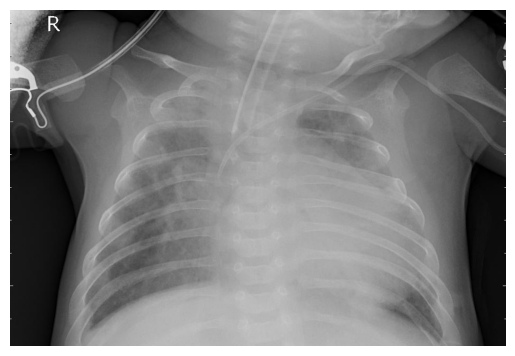

In [5]:
image = cv2.imread(image_path)

print(image.shape)

plt.imshow(cv2.cvtColor(image , cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [6]:
image = cv2.imread(image_path)

# store original image for visualization later
original_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# convert to grayscale
gray_image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

#Resize
resized_image = cv2.resize(gray_image,(224,224))

# normalize 
normalized_image = resized_image/255.0

# add batch dimension and channel dimension
input_image = normalized_image.reshape(1,224,224,1)

print(input_image.shape)

(1, 224, 224, 1)


In [7]:
predictions = model.predict(input_image)

print("Prediction Probability:" , predictions[0][0])

if predictions[0][0] >0.5:
    print("Prediction : Pneumonia")
else:
    print("Prediction : Normal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
Prediction Probability: 0.9999714
Prediction : Pneumonia


In [8]:
for layer in model.layers:
    print(layer.name , layer.output.shape)

conv2d (None, 222, 222, 32)
max_pooling2d (None, 111, 111, 32)
conv2d_1 (None, 109, 109, 64)
max_pooling2d_1 (None, 54, 54, 64)
conv2d_2 (None, 52, 52, 128)
max_pooling2d_2 (None, 26, 26, 128)
flatten (None, 86528)
dense (None, 128)
dropout (None, 128)
dense_1 (None, 1)


In [12]:
print(tf.__version__)
print(tf.keras.__version__)

2.21.0
3.15.0


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,505,541 (127.81 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,337,028 (85.21 MB)

In [14]:
last_conv_layer_name = ...

grad_model = ...

In [15]:
last_conv_layer_name = "conv2d_2"

last_conv_layer = model.get_layer(last_conv_layer_name)

conv_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=last_conv_layer.output
)

classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])

x = classifier_input
start = False

for layer in model.layers:
    if layer.name == last_conv_layer_name:
        start = True
        continue
    if start:
        x = layer(x)

classifier_model = tf.keras.models.Model(classifier_input, x)

In [16]:
input_tensor = tf.convert_to_tensor(input_image, dtype=tf.float32)

with tf.GradientTape() as tape:
    conv_outputs = conv_model(input_tensor)
    tape.watch(conv_outputs)
    predictions = classifier_model(conv_outputs)
    loss = predictions[:, 0]

gradients = tape.gradient(loss, conv_outputs)

print(gradients is None)
print(gradients.shape)
print(predictions.numpy())

False
(1, 52, 52, 128)
[[0.9999714]]


In [19]:
pooled_gradients = tf.reduce_mean(gradients, axis = (0,1,2))

print(pooled_gradients.shape)

(128,)


In [20]:
conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_gradients[...,tf.newaxis]
heatmap = tf.squeeze(heatmap)

print(heatmap.shape)

(52, 52)


In [22]:
heatmap = tf.maximum(heatmap,0)

In [23]:
heatmap = heatmap / tf.reduce_max(heatmap)

In [24]:
heatmap = heatmap.numpy()
type(heatmap)

numpy.ndarray

In [25]:
heatmap = cv2.resize(heatmap,(224,224))

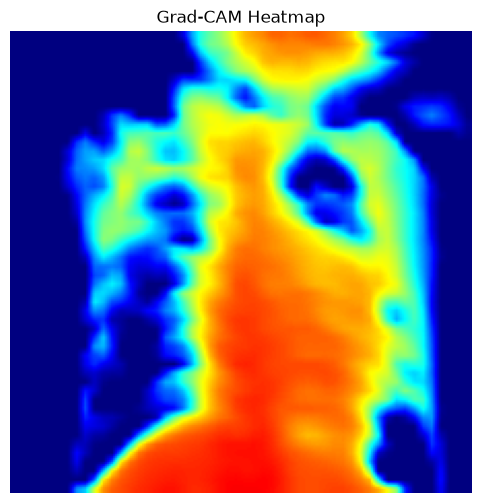

In [28]:
heatmap_uint8 = np.uint8(225 * heatmap)

colored_heatmap = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

colored_heatmap = cv2.cvtColor(
    colored_heatmap,
    cv2.COLOR_BGR2RGB 
)

plt.figure(figsize=(6,6))
plt.imshow(colored_heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

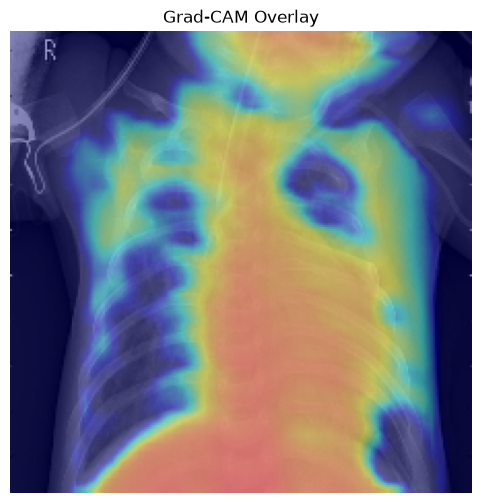

In [31]:
original_resized = cv2.resize(original_image, (224, 224))

superimposed_image = cv2.addWeighted(
    original_resized,
    0.6,
    colored_heatmap,
    0.4,
    0
)

plt.figure(figsize=(6,6))
plt.imshow(superimposed_image)
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()

In [33]:
confidence = float(predictions.numpy()[0][0])

if confidence>0.5:
    predicted_label = "Pneumonia"
    confidence_percent = confidence * 100
else:
    predicted_label = "Normal"
    confidence_percent = (1-confidence)*100

print(f"Prediction : {predicted_label}")
print(f"Confidence : {confidence_percent:.2f}%")

Prediction : Pneumonia
Confidence : 100.00%


In [43]:
def predict_xray(image_path):
    image = cv2.imread(image_path)

    if image is None:
        print("Image not found. Please check the path.")
        return

    original_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized_image = cv2.resize(gray_image, (224, 224))
    normalized_image = resized_image / 255.0
    input_image = normalized_image.reshape(1, 224, 224, 1)

    input_tensor = tf.convert_to_tensor(input_image, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(input_tensor)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs)
        loss = predictions[:, 0]

    gradients = tape.gradient(loss, conv_outputs)

    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / tf.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap)

    colored_heatmap = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    colored_heatmap = cv2.cvtColor(
        colored_heatmap,
        cv2.COLOR_BGR2RGB
    )

    original_resized = cv2.resize(original_image, (224, 224))

    superimposed_image = cv2.addWeighted(
        original_resized,
        0.6,
        colored_heatmap,
        0.4,
        0
    )

    confidence = float(predictions.numpy()[0][0])

    if confidence > 0.5:
        predicted_label = "Pneumonia"
        confidence_percent = confidence * 100
    else:
        predicted_label = "Normal"
        confidence_percent = (1 - confidence) * 100

    print(f"Prediction: {predicted_label}")
    print(f"Confidence: {confidence_percent:.2f}%")

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_resized)
    plt.title("Original X-ray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(colored_heatmap)
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_image)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")

    plt.suptitle(
    f"Prediction: {predicted_label} | Confidence: {confidence_percent:.2f}%",
    fontsize=16,
    fontweight="bold"
)

    plt.show()

import os

image_name = os.path.basename(image_path)

save_path = os.path.join(
    "../results",
    f"gradcam_{image_name}"
)

cv2.imwrite(
    save_path,
    cv2.cvtColor(superimposed_image, cv2.COLOR_RGB2BGR)
)

print(f"Saved at: {save_path}")

print("Grad-CAM overlay saved successfully!")

Saved at: ../results\gradcam_person1_virus_6.jpeg
Grad-CAM overlay saved successfully!


Prediction: Pneumonia
Confidence: 59.34%


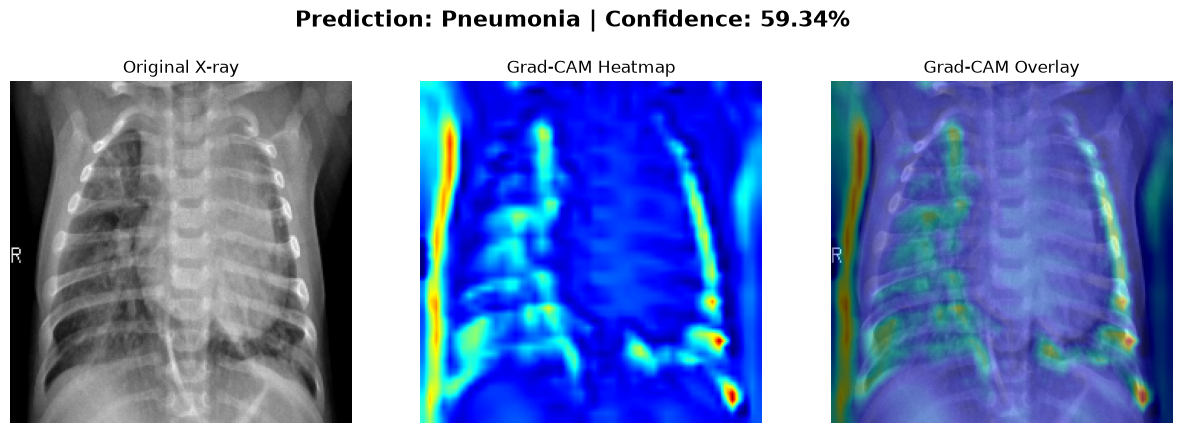

In [44]:
predict_xray(r"D:\chest xray\chest_xray\test\PNEUMONIA\person100_bacteria_475.jpeg")

In [37]:
import os

normal_path = r"D:\chest xray\chest_xray\test\NORMAL"

print(os.listdir(normal_path)[:10])

['IM-0001-0001.jpeg', 'IM-0003-0001.jpeg', 'IM-0005-0001.jpeg', 'IM-0006-0001.jpeg', 'IM-0007-0001.jpeg', 'IM-0009-0001.jpeg', 'IM-0010-0001.jpeg', 'IM-0011-0001-0001.jpeg', 'IM-0011-0001-0002.jpeg', 'IM-0011-0001.jpeg']


Prediction: Normal
Confidence: 68.47%


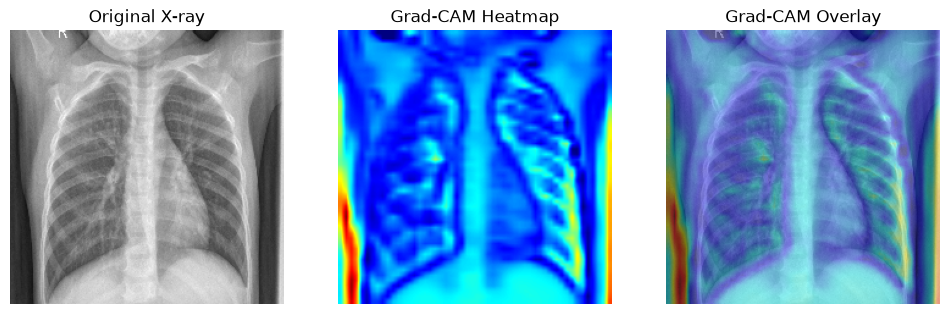

In [38]:
predict_xray(r"D:\chest xray\chest_xray\test\NORMAL\IM-0009-0001.jpeg")

In [39]:
plt.suptitle(
    f"Prediction: {predicted_label} | Confidence: {confidence_percent:.2f}%",
    fontsize=16,
    fontweight="bold"
)
plt.show()

<Figure size 640x480 with 0 Axes>